# Prueba 4 - Variantes de ensamblado de modelos

Este notebook hace lo siguiente:

1. Carga los modelos entrenados del pipeline SOB4ES: 3 familias single-target
   (Ridge, RF, XGBoost) y 5 familias multisalida (RF, XGBoost, RegressorChain,
   MLP, MLP con loss personalizada).
2. Ejecuta el smoke test habitual sobre **todo `eval.csv`** (no una muestra).
3. Separa `eval.csv` en meta-train/holdout, y calcula sobre el meta-train los pesos,
   ranking y coeficientes necesarios para las variantes que se calibran con datos.
4. Compara, todas sobre el mismo holdout, **5 formas de combinar los modelos base**:
   - **Media simple**: peso igual para todos.
   - **Media ponderada (R2)**: pesos proporcionales al R2 de cada modelo.
   - **Top-k**: media simple, pero solo entre los `K_TOP` mejores modelos.
   - **Mediana**: mas robusta a un modelo atipico (como Ridge) que la media.
   - **Stacking convexo**: pesos `w >= 0`, `sum(w) = 1`, optimizados en meta-train.

## Por que hay un holdout (y no se evalua todo sobre `eval.csv` completo)

La media simple y la mediana no calibran nada con datos, asi que podrian evaluarse
sobre las 65 filas de `eval.csv` sin problema. Pero la media ponderada, el top-k y el
stacking convexo **si calibran algo con datos** (pesos, ranking, coeficientes): si se
calibraran y evaluaran sobre las mismas filas, el resultado quedaria inflado (el
metodo "ha visto" la respuesta correcta de antemano). Para que las 5 variantes sean
comparables entre si en igualdad de condiciones, todas se evaluan sobre el mismo
holdout que no se ha usado para calibrar nada.

## 1. Configuración y carga de librerías 

- `MODELS_DIR`: carpeta donde estan guardados los modelos entrenados.
- `EVAL_PATH`: ruta a `eval.csv`.
- `FEATURES_AUTORIZADAS`: las 34 variables de entrada (mismo orden que en el resto del pipeline).
- `TARGETS_ORDER`: los 21 targets **en el mismo orden** en que los modelos multisalida
  fueron entrenados (necesario para poder indexar su salida). Si no lo recuerdas de memoria,
  miralo en el notebook de entrenamiento multisalida (columna `y` usada en `.fit`).
- `TARGETS_TO_TEST`: el subconjunto de targets con los que se prueba este ensamblado
  (por defecto los dos prioritarios + uno mas a elegir).
- `SHOW_ENSEMBLE_MEMBERS`: si es `True`, la seccion 3b imprime el R2 de cada miembro
  individual de cada familia multisalida antes de promediar (util para depurar). No
  afecta a los resultados finales, es solo informativo.


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerias cargadas correctamente...")

MODELS_DIR = Path("output/models")   
EVAL_PATH = Path("input/eval.csv")   

TARGETS_ORDER = [
    # Shannon
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

# Targets con los que se prueba el ensamblado por media + otros métodos.
TARGETS_TO_TEST = [
    # Shannon 
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
]

SHOW_ENSEMBLE_MEMBERS = False  # True para depurar el detalle de cada miembro de cada familia

META_TEST_SIZE = 0.3  # proporcion de eval.csv reservada como holdout para evaluar las variantes
K_TOP = 4             # numero de modelos que se quedan en la variante top-k

assert all(t in TARGETS_ORDER for t in TARGETS_TO_TEST), (
    "Algun target de TARGETS_TO_TEST no esta en TARGETS_ORDER - revisa la configuracion."
)


Librerias cargadas correctamente...


## 2.- Carga de `eval.csv`

In [2]:
eval_df = pd.read_csv(EVAL_PATH)

missing_features = [f for f in FEATURES_AUTORIZADAS if f not in eval_df.columns]
missing_targets = [t for t in TARGETS_ORDER if t not in eval_df.columns]
if missing_features:
    print(f"[AVISO] Faltan {len(missing_features)} features en eval.csv: {missing_features[:5]}...")
if missing_targets:
    print(f"[AVISO] Faltan {len(missing_targets)} targets en eval.csv: {missing_targets[:5]}...")

X_eval = eval_df[FEATURES_AUTORIZADAS]
y_eval = eval_df[TARGETS_ORDER]

print(f"eval.csv: {eval_df.shape[0]} filas, {eval_df.shape[1]} columnas")
print(f"X_eval: {X_eval.shape}  |  y_eval: {y_eval.shape}")


eval.csv: 65 filas, 71 columnas
X_eval: (65, 34)  |  y_eval: (65, 21)


## 3.- Definición y carga de los modelos base

Todos los modelos son ensamblados internos de varios miembros entrenados por separado,
**salvo Ridge, que es un unico modelo por target (sin ensamblado)**. El resto -
single-target (RF single-target, XGBoost single-target, un ensamblado por target) y
multisalida (RF, XGBoost, RegressorChain, MLP, MLP custom loss, un ensamblado por
familia) - si son ensamblados: 5 miembros en todos salvo RegressorChain, que tiene 10.

`EnsembleWrapper` carga todos los miembros disponibles de una familia (y, si es
single-target, de un target concreto) y promedia su prediccion, de forma que el resto
del notebook trata cada familia como un unico modelo ya consolidado:

- Si es **single-target**, cada miembro ya predice directamente el target -> se
  promedian las predicciones tal cual.
- Si es **multisalida**, cada miembro predice los 21 targets a la vez -> primero se
  selecciona la columna del target pedido en cada miembro y despues se promedia entre
  miembros.

Notas sobre el formato de cada tipo de modelo:

- **Ridge, RF y XGBoost** (single y multi) se guardan como `.pkl` y se cargan igual,
  con `joblib.load`.
- **MLP y MLP custom loss**: cada miembro tiene sus propios pesos (`.pt`, un
  `state_dict`), pero el config (`.pkl`) con la arquitectura usada al entrenar es
  **unico por familia** (no uno por miembro): todos los miembros de "MLP multisalida"
  comparten el mismo config, y lo mismo para "MLP custom loss".

Si un fichero (o un miembro del ensamblado) no existe o falla la carga, se **omite con
un aviso** en vez de interrumpir el notebook, asi puedes ejecutar esto aunque todavia no
tengas todos los modelos entrenados.


In [3]:
def load_sklearn(path):
    return joblib.load(path)


def load_mlp_member(weights_path, config_path):
    import torch
    import torch.nn as nn

    config = joblib.load(config_path)

    def _cfg_get(key, default):
        # El config puede venir como dict o como un objeto (p.ej. dataclass/Namespace).
        if isinstance(config, dict):
            return config.get(key, default)
        return getattr(config, key, default)

    class GenericMLP(nn.Module):
        def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.0):
            super().__init__()
            layers = []
            prev_dim = input_dim
            for h in hidden_dims:
                layers.append(nn.Linear(prev_dim, h))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_dim = h
            layers.append(nn.Linear(prev_dim, output_dim))
            self.red = nn.Sequential(*layers)

        def forward(self, x):
            return self.red(x)

        def predict(self, X):
            self.eval()
            with torch.no_grad():
                X_t = torch.as_tensor(np.asarray(X), dtype=torch.float32)
                return self.red(X_t).numpy()

    model = GenericMLP(
        input_dim=_cfg_get("input_dim", len(FEATURES_AUTORIZADAS)),
        hidden_dims=_cfg_get("hidden", [64, 32]),
        output_dim=_cfg_get("output_dim", len(TARGETS_ORDER)),
        dropout=_cfg_get("dropout", 0.0),
    )
    state_dict = torch.load(Path(weights_path), map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    return model


class EnsembleWrapper:
    '''Modelo (single-target o multisalida) guardado como ensamblado de varios miembros
    entrenados por separado. predict() promedia la prediccion de todos los miembros
    disponibles. Si falta algun miembro (fichero no encontrado, error de carga),
    simplemente se promedia con los que si se cargaron.

    kind="single": cada miembro predice directamente el target -> se promedian tal cual.
    kind="multi": cada miembro predice todos los targets a la vez -> primero se
    selecciona la columna del target pedido en cada miembro y despues se promedia.
    '''

    def __init__(self, key, label, members, kind, targets_order=None):
        self.key = key
        self.label = label
        self.members = members
        self.kind = kind
        self.targets_order = targets_order

    def predict(self, X, target=None):
        member_preds = []
        for model in self.members:
            preds = np.asarray(model.predict(X))
            if self.kind == "multi":
                if preds.ndim == 1:
                    preds = preds.reshape(-1, 1)
                idx = self.targets_order.index(target)
                preds = preds[:, idx]
            else:
                preds = preds.reshape(-1)
            member_preds.append(preds)
        return np.mean(np.column_stack(member_preds), axis=1)


def load_ensemble_members(loader, path_template, n_members, loader_kwargs=None, **template_kwargs):
    '''Carga los n_members ficheros de un ensamblado, tolerando fallos parciales.
    loader_kwargs son argumentos fijos que se pasan a loader() en cada miembro (p.ej.
    un config compartido por toda la familia, en vez de uno por miembro).
    Devuelve (members, errors), donde errors es una lista de (indice, tipo_error, mensaje).
    '''
    loader_kwargs = loader_kwargs or {}
    members = []
    errors = []
    for i in range(n_members):
        path = Path(path_template.format(i=i, **template_kwargs))
        try:
            members.append(loader(path, **loader_kwargs))
        except Exception as e:
            errors.append((i, type(e).__name__, str(e)))
    return members, errors


SINGLE_MODEL_CONFIGS = [
    {"key": "ridge",      "label": "Ridge",                 "loader": load_sklearn, "path_template": str(MODELS_DIR / "reg/ridge_prod_{target}.pkl"),     "n_members": 1},
    {"key": "rf_single",  "label": "RF single-target",      "loader": load_sklearn, "path_template": str(MODELS_DIR / "rf/rf_prod_{target}_m{i}.pkl"),     "n_members": 5},
    {"key": "xgb_single", "label": "XGBoost single-target", "loader": load_sklearn, "path_template": str(MODELS_DIR / "xgb/xgb_prod_{target}_exp{i}.pkl"),   "n_members": 5},
]

MULTI_MODEL_CONFIGS = [
    {"key": "rf_multi",   "label": "RF multisalida",      "loader": load_sklearn,     "path_template": str(MODELS_DIR / "rf_multi/rf_multi_m{i}.pkl"),    "n_members": 5},
    {"key": "xgb_multi",  "label": "XGBoost multisalida", "loader": load_sklearn,     "path_template": str(MODELS_DIR / "xgb_multi/xgb_multi_exp{i}.pkl"), "n_members": 5},
    {"key": "regchain",   "label": "RegressorChain",      "loader": load_sklearn,     "path_template": str(MODELS_DIR / "chain/chain_{i}.pkl"),       "n_members": 10},
    {"key": "mlp_multi",  "label": "MLP multisalida",     "loader": load_mlp_member,  "path_template": str(MODELS_DIR / "mlp/mlp_prod_{i}.pt"),         "n_members": 5,
     "loader_kwargs": {"config_path": str(MODELS_DIR / "mlp/mlp_config.pkl")}},
    {"key": "mlp_custom", "label": "MLP custom loss",     "loader": load_mlp_member,  "path_template": str(MODELS_DIR / "mlp_custom/mlp_custom_{i}.pt"),  "n_members": 5,
     "loader_kwargs": {"config_path": str(MODELS_DIR / "mlp_custom/mlp_custom_config.pkl")}},
]

loaded_single = {}   # (key, target) -> EnsembleWrapper
loaded_multi = {}    # key -> EnsembleWrapper

for cfg in SINGLE_MODEL_CONFIGS:
    for target in TARGETS_TO_TEST:
        members, errors = load_ensemble_members(cfg["loader"], cfg["path_template"], cfg["n_members"],
                                                  loader_kwargs=cfg.get("loader_kwargs"), target=target)
        if members:
            loaded_single[(cfg["key"], target)] = EnsembleWrapper(cfg["key"], cfg["label"], members, kind="single")
            print(f"OK    {cfg['label']:22s} [{target}] cargado ({len(members)}/{cfg['n_members']} miembros)")
            if errors:
                print(f"      [AVISO] {len(errors)} miembro(s) no disponible(s), se promedia solo con el resto -> primer error: {errors[0][1]}: {errors[0][2]}")
        else:
            print(f"FALLO {cfg['label']:22s} [{target}] omitido -> no se cargo ningun miembro (0/{cfg['n_members']})")
            if errors:
                print(f"      -> primer error: {errors[0][1]}: {errors[0][2]}")

for cfg in MULTI_MODEL_CONFIGS:
    members, errors = load_ensemble_members(cfg["loader"], cfg["path_template"], cfg["n_members"],
                                             loader_kwargs=cfg.get("loader_kwargs"))
    if members:
        loaded_multi[cfg["key"]] = EnsembleWrapper(cfg["key"], cfg["label"], members, kind="multi", targets_order=TARGETS_ORDER)
        print(f"OK    {cfg['label']:22s} cargado ({len(members)}/{cfg['n_members']} miembros)")
        if errors:
            print(f"      [AVISO] {len(errors)} miembro(s) no disponible(s), se promedia solo con el resto -> primer error: {errors[0][1]}: {errors[0][2]}")
    else:
        print(f"FALLO {cfg['label']:22s} omitido -> no se cargo ningun miembro (0/{cfg['n_members']})")
        if errors:
            print(f"      -> primer error: {errors[0][1]}: {errors[0][2]}")

print(f"\nModelos disponibles: {len(loaded_single)} single-target (por target) + {len(loaded_multi)} familias multisalida")


OK    Ridge                  [nematode_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [macro_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [earthworm_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [orib_shannon_z] cargado (1/1 miembros)
OK    Ridge                  [macro_order_richness_z] cargado (1/1 miembros)
OK    Ridge                  [earthworm_richness_z] cargado (1/1 miembros)
OK    Ridge                  [orib_species_richness_z] cargado (1/1 miembros)
OK    Ridge                  [meso_species_richness_z] cargado (1/1 miembros)
OK    RF single-target       [nematode_shannon_z] cargado (5/5 miembros)
OK    RF single-target       [macro_shannon_z] cargado (5/5 miembros)
OK    RF single-target       [earthworm_shannon_z] cargado (5/5 miembros)
OK    RF single-target       [orib_shannon_z] cargado (5/5 miembros)


OK    RF single-target       [macro_order_richness_z] cargado (5/5 miembros)
OK    RF single-target       [earthworm_richness_z] cargado (5/5 miembros)
OK    RF single-target       [orib_species_richness_z] cargado (5/5 miembros)
OK    RF single-target       [meso_species_richness_z] cargado (5/5 miembros)


OK    XGBoost single-target  [nematode_shannon_z] cargado (5/5 miembros)
OK    XGBoost single-target  [macro_shannon_z] cargado (5/5 miembros)
OK    XGBoost single-target  [earthworm_shannon_z] cargado (5/5 miembros)
OK    XGBoost single-target  [orib_shannon_z] cargado (5/5 miembros)
OK    XGBoost single-target  [macro_order_richness_z] cargado (5/5 miembros)
OK    XGBoost single-target  [earthworm_richness_z] cargado (5/5 miembros)
OK    XGBoost single-target  [orib_species_richness_z] cargado (5/5 miembros)
OK    XGBoost single-target  [meso_species_richness_z] cargado (5/5 miembros)
OK    RF multisalida         cargado (5/5 miembros)


OK    XGBoost multisalida    cargado (5/5 miembros)


OK    RegressorChain         cargado (10/10 miembros)


OK    MLP multisalida        cargado (5/5 miembros)
OK    MLP custom loss        cargado (5/5 miembros)

Modelos disponibles: 24 single-target (por target) + 5 familias multisalida


### 3b.- (Opcional) Inspeccion de miembros individuales de cada ensamblado

Solo se ejecuta si `SHOW_ENSEMBLE_MEMBERS = True` en la seccion 1. Util para depurar
si un miembro concreto (de un modelo single-target o de una familia multisalida) esta
dando resultados muy distintos al resto antes de que se pierda esa informacion al
promediar. No afecta a los resultados de las secciones siguientes.


In [4]:
if SHOW_ENSEMBLE_MEMBERS:
    print("--- Modelos single-target ---")
    for (key, target), wrapper in loaded_single.items():
        y_true_t = y_eval[target].values
        print(f"\n{wrapper.label} [{target}] ({len(wrapper.members)} miembros cargados)")
        for i, model in enumerate(wrapper.members):
            preds = np.asarray(model.predict(X_eval)).reshape(-1)
            r2 = r2_score(y_true_t, preds)
            print(f"  miembro {i} | R2={r2: .4f}")

    print("\n--- Familias multisalida ---")
    for key, wrapper in loaded_multi.items():
        print(f"\n{wrapper.label} ({len(wrapper.members)} miembros cargados)")
        for target in TARGETS_TO_TEST:
            idx = TARGETS_ORDER.index(target)
            y_true_t = y_eval[target].values
            for i, model in enumerate(wrapper.members):
                preds = np.asarray(model.predict(X_eval))
                if preds.ndim == 1:
                    preds = preds.reshape(-1, 1)
                preds_t = preds[:, idx]
                r2 = r2_score(y_true_t, preds_t)
                print(f"  miembro {i} | {target:22s} | R2={r2: .4f}")
else:
    print("SHOW_ENSEMBLE_MEMBERS = False -> seccion omitida (cambia el flag en la seccion 1 para activarla).")


SHOW_ENSEMBLE_MEMBERS = False -> seccion omitida (cambia el flag en la seccion 1 para activarla).


## 4.- Smoke test sobre `eval.csv` completo

Mismas comprobaciones que el smoke test habitual de los notebooks de modelo (predice sin
error, sin NaN/Inf, tamano de salida correcto), pero aqui sobre **todas** las filas de
`eval.csv` en vez de una muestra pequena. Se reutilizan las predicciones para las secciones
siguientes, asi no se predice dos veces. Cada familia multisalida ya llega aqui como una
unica prediccion promediada entre sus miembros.


In [5]:
def smoke_test(wrapper, X, y_true, target):
    try:
        preds = wrapper.predict(X, target=target)
    except Exception as e:
        print(f"[SMOKE TEST] {wrapper.label:22s} | {target:22s} | ERROR al predecir -> {type(e).__name__}: {e}")
        return None

    preds = np.asarray(preds, dtype=float).reshape(-1)
    shape_ok = preds.shape[0] == len(X)
    n_nan = int(np.isnan(preds).sum())
    n_inf = int(np.isinf(preds).sum())
    ok = shape_ok and n_nan == 0 and n_inf == 0
    r2 = r2_score(y_true, preds) if ok else float("nan")
    status = "OK" if ok else "REVISAR"
    print(f"[SMOKE TEST] {wrapper.label:22s} | {target:22s} | filas={len(preds):5d} | "
          f"NaN={n_nan} | Inf={n_inf} | R2={r2: .4f} | {status}")
    return preds if ok else None


# predictions[target][label] = np.array de predicciones (solo si paso el smoke test)
predictions = {t: {} for t in TARGETS_TO_TEST}

for target in TARGETS_TO_TEST:
    y_true_t = y_eval[target].values
    print(f"\n--- {target} ---")

    for (key, t), wrapper in loaded_single.items():
        if t != target:
            continue
        preds = smoke_test(wrapper, X_eval, y_true_t, target)
        if preds is not None:
            predictions[target][wrapper.label] = preds

    for key, wrapper in loaded_multi.items():
        preds = smoke_test(wrapper, X_eval, y_true_t, target)
        if preds is not None:
            predictions[target][wrapper.label] = preds



--- nematode_shannon_z ---
[SMOKE TEST] Ridge                  | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.0112 | OK
[SMOKE TEST] RF single-target       | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1693 | OK
[SMOKE TEST] XGBoost single-target  | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1637 | OK


[SMOKE TEST] RF multisalida         | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1545 | OK


[SMOKE TEST] XGBoost multisalida    | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.2228 | OK


[SMOKE TEST] RegressorChain         | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1467 | OK
[SMOKE TEST] MLP multisalida        | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.1180 | OK
[SMOKE TEST] MLP custom loss        | nematode_shannon_z     | filas=   65 | NaN=0 | Inf=0 | R2= 0.0690 | OK

--- macro_shannon_z ---
[SMOKE TEST] Ridge                  | macro_shannon_z        | filas=   65 | NaN=0 | Inf=0 | R2= 0.1257 | OK
[SMOKE TEST] RF single-target       | macro_shannon_z        | filas=   65 | NaN=0 | Inf=0 | R2= 0.3199 | OK
[SMOKE TEST] XGBoost single-target  | macro_shannon_z        | filas=   65 | NaN=0 | Inf=0 | R2= 0.2601 | OK


[SMOKE TEST] RF multisalida         | macro_shannon_z        | filas=   65 | NaN=0 | Inf=0 | R2= 0.2000 | OK
[SMOKE TEST] XGBoost multisalida    | macro_shannon_z        | filas=   65 | NaN=0 | Inf=0 | R2= 0.3771 | OK


...

[SMOKE TEST] RegressorChain         | earthworm_richness_z   | filas=   65 | NaN=0 | Inf=0 | R2= 0.5359 | OK
[SMOKE TEST] MLP multisalida        | earthworm_richness_z   | filas=   65 | NaN=0 | Inf=0 | R2= 0.5176 | OK
[SMOKE TEST] MLP custom loss        | earthworm_richness_z   | filas=   65 | NaN=0 | Inf=0 | R2= 0.4997 | OK

--- orib_species_richness_z ---
[SMOKE TEST] Ridge                  | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.0921 | OK
[SMOKE TEST] RF single-target       | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.2034 | OK
[SMOKE TEST] XGBoost single-target  | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.1259 | OK


[SMOKE TEST] RF multisalida         | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.2386 | OK
[SMOKE TEST] XGBoost multisalida    | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.2800 | OK


[SMOKE TEST] RegressorChain         | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.2026 | OK
[SMOKE TEST] MLP multisalida        | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.2596 | OK
[SMOKE TEST] MLP custom loss        | orib_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2= 0.2488 | OK

--- meso_species_richness_z ---
[SMOKE TEST] Ridge                  | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.0959 | OK
[SMOKE TEST] RF single-target       | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.0438 | OK
[SMOKE TEST] XGBoost single-target  | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.0592 | OK


[SMOKE TEST] RF multisalida         | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.0255 | OK
[SMOKE TEST] XGBoost multisalida    | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.1146 | OK


[SMOKE TEST] RegressorChain         | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.0400 | OK
[SMOKE TEST] MLP multisalida        | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.2753 | OK
[SMOKE TEST] MLP custom loss        | meso_species_richness_z | filas=   65 | NaN=0 | Inf=0 | R2=-0.1505 | OK


## 5.- Particion meta-train / holdout

Las variantes de la seccion 7 (media ponderada, top-k, stacking convexo) **calibran
algo con datos** (pesos, ranking, coeficientes), asi que evaluarlas sobre las mismas
filas que se usan para calibrarlas inflaria el resultado (el metodo "ha visto" la
respuesta correcta de antemano). Por eso se separan las filas de `eval.csv` en dos
bloques: uno para calibrar (meta-train) y otro para evaluar todo -- modelos
individuales y las 5 variantes de combinacion por igual -- (holdout). La mediana y la
media simple no calibran nada, pero se evaluan tambien sobre el holdout para que la
comparacion final sea homogenea.


In [6]:
idx_all = np.arange(len(eval_df))
idx_train, idx_holdout = train_test_split(idx_all, test_size=META_TEST_SIZE, random_state=RANDOM_STATE)

print(f"Filas totales en eval.csv: {len(idx_all)}")
print(f"Filas para calibrar pesos/seleccion (meta-train): {len(idx_train)}")
print(f"Filas para evaluar todo (holdout):                 {len(idx_holdout)}")


Filas totales en eval.csv: 65
Filas para calibrar pesos/seleccion (meta-train): 45
Filas para evaluar todo (holdout):                 20


## 6.- Calculo de pesos, ranking y coeficientes de stacking (sobre meta-train)

Para cada target:

- **R2 por modelo** en meta-train (base para las variantes ponderada y top-k).
- **Pesos de la media ponderada**: `max(R2, 0)` normalizado para sumar 1 (un modelo
  con R2 negativo en meta-train no deberia restar, asi que se recorta a 0 antes de
  normalizar).
- **Ranking para top-k**: los `K_TOP` modelos con mejor R2 en meta-train.
- **Coeficientes del stacking con pesos no negativos que suman 1**: se resuelve un
  problema de optimizacion (SLSQP) que minimiza el error cuadratico en meta-train
  sujeto a `w >= 0` y `sum(w) = 1`.


In [7]:
def fit_convex_weights(X_meta_train, y_meta_train):
    '''Encuentra pesos w >= 0, sum(w) = 1, que minimizan el MSE en meta-train.'''
    n_models = X_meta_train.shape[1]
    w0 = np.full(n_models, 1.0 / n_models)

    def objective(w):
        preds = X_meta_train @ w
        return np.mean((preds - y_meta_train) ** 2)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n_models

    result = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        print(f"      [AVISO] Optimizacion de pesos no convergio ({result.message}); se usan pesos uniformes.")
        return w0
    return result.x


variant_info = {}  # target -> dict con model_labels, weights, top_k_labels, convex_weights

for target in TARGETS_TO_TEST:
    model_labels = list(predictions[target].keys())
    if not model_labels:
        print(f"[AVISO] {target}: no hay modelos disponibles, no se pueden calcular pesos.")
        continue

    X_full = np.column_stack([predictions[target][lbl] for lbl in model_labels])
    y_target = y_eval[target].values
    X_train, y_train = X_full[idx_train], y_target[idx_train]

    r2_train = {lbl: r2_score(y_train, X_train[:, i]) for i, lbl in enumerate(model_labels)}

    raw_weights = np.array([max(r2_train[lbl], 0.0) for lbl in model_labels])
    if raw_weights.sum() == 0:
        print(f"[AVISO] {target}: todos los modelos tienen R2<=0 en meta-train, se usan pesos uniformes.")
        weighted_weights = np.full(len(model_labels), 1.0 / len(model_labels))
    else:
        weighted_weights = raw_weights / raw_weights.sum()

    k = min(K_TOP, len(model_labels))
    top_k_labels = sorted(model_labels, key=lambda lbl: r2_train[lbl], reverse=True)[:k]

    convex_weights = fit_convex_weights(X_train, y_train)

    variant_info[target] = {
        "model_labels": model_labels,
        "r2_train": r2_train,
        "weighted_weights": weighted_weights,
        "top_k_labels": top_k_labels,
        "convex_weights": convex_weights,
    }

    print(f"\n--- {target} ---")
    print("R2 en meta-train por modelo:", {k: round(v, 3) for k, v in r2_train.items()})
    print("Pesos media ponderada:      ", {lbl: round(w, 3) for lbl, w in zip(model_labels, weighted_weights)})
    print(f"Top-{k}:                     {top_k_labels}")
    print("Pesos stacking convexo:     ", {lbl: round(w, 3) for lbl, w in zip(model_labels, convex_weights)})



--- nematode_shannon_z ---
R2 en meta-train por modelo: {'Ridge': 0.038, 'RF single-target': 0.167, 'XGBoost single-target': 0.173, 'RF multisalida': 0.178, 'XGBoost multisalida': 0.201, 'RegressorChain': 0.144, 'MLP multisalida': 0.119, 'MLP custom loss': 0.095}
Pesos media ponderada:       {'Ridge': np.float64(0.034), 'RF single-target': np.float64(0.15), 'XGBoost single-target': np.float64(0.155), 'RF multisalida': np.float64(0.16), 'XGBoost multisalida': np.float64(0.18), 'RegressorChain': np.float64(0.129), 'MLP multisalida': np.float64(0.107), 'MLP custom loss': np.float64(0.085)}
Top-4:                     ['XGBoost multisalida', 'RF multisalida', 'XGBoost single-target', 'RF single-target']
Pesos stacking convexo:      {'Ridge': np.float64(0.0), 'RF single-target': np.float64(0.0), 'XGBoost single-target': np.float64(0.0), 'RF multisalida': np.float64(0.319), 'XGBoost multisalida': np.float64(0.681), 'RegressorChain': np.float64(0.0), 'MLP multisalida': np.float64(0.0), 'MLP c

## 7.- Evaluación de todas las variantes sobre el holdout

Se calculan 5 formas de combinar los modelos disponibles, todas sobre las mismas
filas de holdout:

1. **Media simple**: la de siempre, peso igual para todos.
2. **Media ponderada (R2)**: pesos proporcionales al R2 de cada modelo en meta-train.
3. **Top-k**: media simple, pero solo entre los `K_TOP` mejores modelos.
4. **Mediana**: mas robusta a un modelo atipico (como Ridge) que la media.
5. **Stacking convexo**: combinacion lineal con pesos `w >= 0`, `sum(w) = 1`,
   optimizados en meta-train.


In [8]:
holdout_predictions = {t: {} for t in TARGETS_TO_TEST}

for target in TARGETS_TO_TEST:
    if target not in variant_info:
        continue
    info = variant_info[target]
    model_labels = info["model_labels"]

    X_holdout = np.column_stack([predictions[target][lbl] for lbl in model_labels])[idx_holdout]

    # Modelos individuales, recortados al holdout
    for i, lbl in enumerate(model_labels):
        holdout_predictions[target][lbl] = X_holdout[:, i]

    # 1. Media simple
    holdout_predictions[target]["Media simple"] = X_holdout.mean(axis=1)

    # 2. Media ponderada por R2
    holdout_predictions[target]["Media ponderada (R2)"] = X_holdout @ info["weighted_weights"]

    # 3. Top-k
    idx_top_k = [model_labels.index(lbl) for lbl in info["top_k_labels"]]
    holdout_predictions[target][f"Top-{len(idx_top_k)}"] = X_holdout[:, idx_top_k].mean(axis=1)

    # 4. Mediana
    holdout_predictions[target]["Mediana"] = np.median(X_holdout, axis=1)

    # 5. Stacking convexo (pesos >= 0, suman 1)
    holdout_predictions[target]["Stacking convexo"] = X_holdout @ info["convex_weights"]


## 8.- Comparativa: modelos individuales vs. las 5 variantes de combinacion

In [9]:
COMBINATION_LABELS = {"Media simple", "Media ponderada (R2)", "Mediana", "Stacking convexo"}
COMBINATION_LABELS |= {lbl for lbl in holdout_predictions.get(TARGETS_TO_TEST[0], {}) if lbl.startswith("Top-")}

rows = []
for target in TARGETS_TO_TEST:
    if target not in variant_info:
        continue
    y_true_holdout = y_eval[target].values[idx_holdout]
    for label, preds in holdout_predictions[target].items():
        rmse = mean_squared_error(y_true_holdout, preds) ** 0.5
        rows.append({
            "target": target,
            "modelo": label,
            "R2": r2_score(y_true_holdout, preds),
            "RMSE": rmse,
            "MAE": mean_absolute_error(y_true_holdout, preds),
            "tipo": "combinacion" if label in COMBINATION_LABELS else "individual",
        })

if not rows:
    print("[AVISO] No hay predicciones de holdout disponibles todavia. "
          "Revisa que los modelos se hayan cargado (seccion 3), que el smoke test haya "
          "pasado (seccion 4) y que los pesos se hayan calculado (seccion 6).")
    results_df = pd.DataFrame(columns=["target", "modelo", "R2", "RMSE", "MAE", "tipo"])
else:
    results_df = pd.DataFrame(rows).sort_values(["target", "R2"], ascending=[True, False]).reset_index(drop=True)

results_df


,target,modelo,R2,RMSE,MAE,tipo
0,earthworm_richness_z,RF single-target,0.512809,0.474454,0.321436,individual
1,earthworm_richness_z,XGBoost multisalida,0.508708,0.476447,0.335824,individual
2,earthworm_richness_z,Stacking convexo,0.502430,0.479481,0.333753,combinacion
3,earthworm_richness_z,XGBoost single-target,0.498934,0.481163,0.358272,individual
4,earthworm_richness_z,Mediana,0.479529,0.490391,0.337147,combinacion
...,...,...,...,...,...,...
99,orib_species_richness_z,RF single-target,-0.118207,0.948033,0.714620,individual
100,orib_species_richness_z,MLP custom loss,-0.149716,0.961297,0.718243,individual
101,orib_species_richness_z,XGBoost multisalida,-0.181075,0.974319,0.686219,individual
102,orib_species_richness_z,Stacking convexo,-0.286666,1.016940,0.748722,combinacion


## 8.1.- Resumen agregado por target

Con muchos targets a la vez, `results_df` tiene demasiadas filas para leerla a ojo.
Esta tabla se queda con una fila por target: el mejor modelo individual, la mejor
variante de combinacion, cual de los dos gana, y si el mejor R2 de ese target es
positivo (es decir, si hay alguna señal predictiva real) o no.

**R2 <= 0 significa que ni el mejor modelo hace mejor que predecir siempre la media**
-- en esos targets el problema no es que metodo de ensamblado usar, sino que
los modelos base no tienen señal util que combinar.

In [10]:
if results_df.empty:
    print("[AVISO] results_df esta vacio. Ejecuta primero las secciones 3-8.")
    summary_df = pd.DataFrame(columns=[
        "target", "mejor_individual", "R2_mejor_individual",
        "mejor_combinacion", "R2_mejor_combinacion", "gana_combinacion", "mejor_R2_global",
    ])
else:
    summary_rows = []
    for target in results_df["target"].unique():
        sub = results_df[results_df["target"] == target]

        individuales = sub[sub["tipo"] == "individual"].sort_values("R2", ascending=False)
        combinaciones = sub[sub["tipo"] != "individual"].sort_values("R2", ascending=False)

        mejor_individual = individuales.iloc[0] if not individuales.empty else None
        mejor_combinacion = combinaciones.iloc[0] if not combinaciones.empty else None

        r2_individual = mejor_individual["R2"] if mejor_individual is not None else float("-inf")
        r2_combinacion = mejor_combinacion["R2"] if mejor_combinacion is not None else float("-inf")

        summary_rows.append({
            "target": target,
            "mejor_individual": mejor_individual["modelo"] if mejor_individual is not None else None,
            "R2_mejor_individual": r2_individual,
            "mejor_combinacion": mejor_combinacion["modelo"] if mejor_combinacion is not None else None,
            "R2_mejor_combinacion": r2_combinacion,
            "gana_combinacion": bool(r2_combinacion > r2_individual),
            "mejor_R2_global": max(r2_individual, r2_combinacion),
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("mejor_R2_global", ascending=False).reset_index(drop=True)

    n_targets = len(summary_df)
    n_gana_combo = int(summary_df["gana_combinacion"].sum())
    n_r2_positivo = int((summary_df["mejor_R2_global"] > 0).sum())

    print(f"Targets evaluados: {n_targets}")
    print(f"Targets donde alguna combinacion supera al mejor individual: "
          f"{n_gana_combo}/{n_targets} ({n_gana_combo / n_targets:.0%})")
    print(f"Targets con señal predictiva real (mejor R2 > 0): "
          f"{n_r2_positivo}/{n_targets} ({n_r2_positivo / n_targets:.0%})")
    print(f"Targets sin señal predictiva (mejor R2 <= 0, ningun modelo le gana a la media): "
          f"{n_targets - n_r2_positivo}")

summary_df

Targets evaluados: 8
Targets donde alguna combinacion supera al mejor individual: 1/8 (12%)
Targets con señal predictiva real (mejor R2 > 0): 7/8 (88%)
Targets sin señal predictiva (mejor R2 <= 0, ningun modelo le gana a la media): 1


,target,mejor_individual,R2_mejor_individual,mejor_combinacion,R2_mejor_combinacion,gana_combinacion,mejor_R2_global
0,earthworm_richness_z,RF single-target,0.512809,Stacking convexo,0.502430,False,0.512809
1,macro_order_richness_z,XGBoost multisalida,0.509020,Top-4,0.447021,False,0.509020
2,macro_shannon_z,RegressorChain,0.372242,Stacking convexo,0.370340,False,0.372242
3,earthworm_shannon_z,RegressorChain,0.366510,Top-4,0.347379,False,0.366510
4,nematode_shannon_z,XGBoost multisalida,0.280802,Stacking convexo,0.239088,False,0.280802
5,meso_species_richness_z,XGBoost single-target,0.051244,Mediana,0.037259,False,0.051244
6,orib_shannon_z,MLP custom loss,0.007893,Media ponderada (R2),0.019553,True,0.019553
7,orib_species_richness_z,RF multisalida,-0.054500,Mediana,-0.067878,False,-0.054500


## 9.- Visualización

Barras de R2 por modelo y target sobre el holdout. Las variantes de combinacion se
resaltan con borde negro para distinguirlas de los modelos individuales.


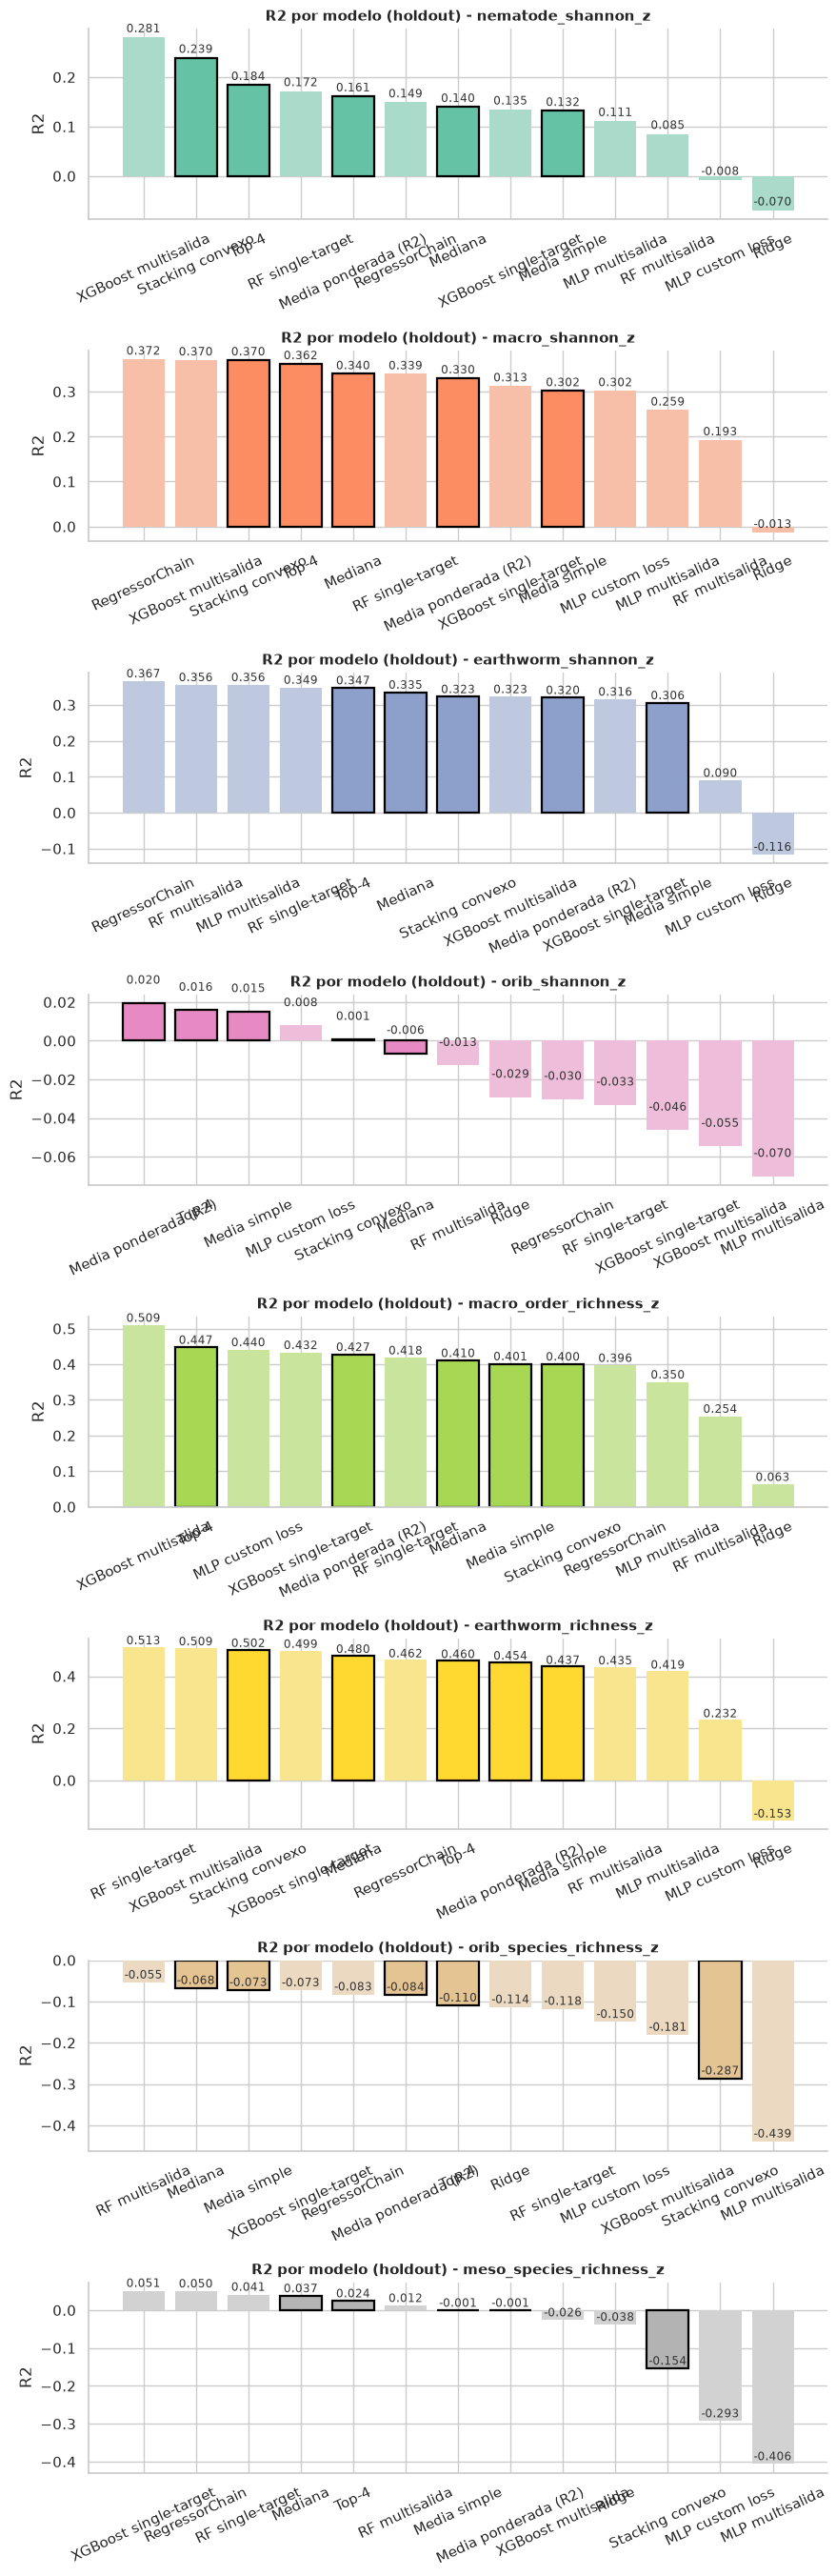

In [11]:
if results_df.empty:
    print("[AVISO] results_df esta vacio, no hay nada que graficar. Ejecuta primero las secciones 3-8.")
else:
    targets_present = [t for t in TARGETS_TO_TEST if t in results_df["target"].unique()]
    palette = sns.color_palette("Set2", n_colors=max(len(targets_present), 3))
    TARGET_COLORS = dict(zip(targets_present, palette))

    fig, axes = plt.subplots(len(targets_present), 1, figsize=(9, 3.4 * len(targets_present)), squeeze=False)

    for ax, target in zip(axes[:, 0], targets_present):
        sub = results_df[results_df["target"] == target].sort_values("R2", ascending=False)
        base_color = TARGET_COLORS[target]
        is_highlighted = sub["tipo"] != "individual"
        colors = [base_color if h else sns.light_palette(base_color, n_colors=3)[1] for h in is_highlighted]
        edgecolors = ["black" if h else "none" for h in is_highlighted]
        linewidths = [1.6 if h else 0 for h in is_highlighted]

        bars = ax.bar(sub["modelo"], sub["R2"], color=colors, edgecolor=edgecolors, linewidth=linewidths)
        for bar, r2 in zip(bars, sub["R2"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{r2:.3f}",
                    ha="center", fontsize=8.5, color="#333333")
        ax.set_title(f"R2 por modelo (holdout) - {target}", fontsize=11, fontweight="bold")
        ax.set_ylabel("R2")
        ax.tick_params(axis="x", rotation=25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig("output/r2_comparativa_sin_modelos.png", dpi=300, bbox_inches="tight")
    plt.show()
